![PIC UPV PERTE Chip Chair Logo](https://www.pic-chair.upv.es/wp-content/uploads/2024/05/logo-upv-horizontal.png)
![PIC UPV PERTE Chip Chair Logo](https://www.pic-chair.upv.es/wp-content/uploads/2024/06/logos-perte-chip-1024x119.png)

# Laboratory 4. Process Design Kit (PDK) and Layout

In [77]:
import gdsfactory as gf

## 1. Technology

We will work with the **demo UPVfab PDK**. (There are some other open-source PDKs, in other technologies, feel free to search if interested)

In [78]:
from upvfab.sin300.cband import PDK, cells

Let's view the layer distribution of this PDK. In our case, for the passive devices we will only use the **Layer 1**. 

2026-06-12 12:44:05.754 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


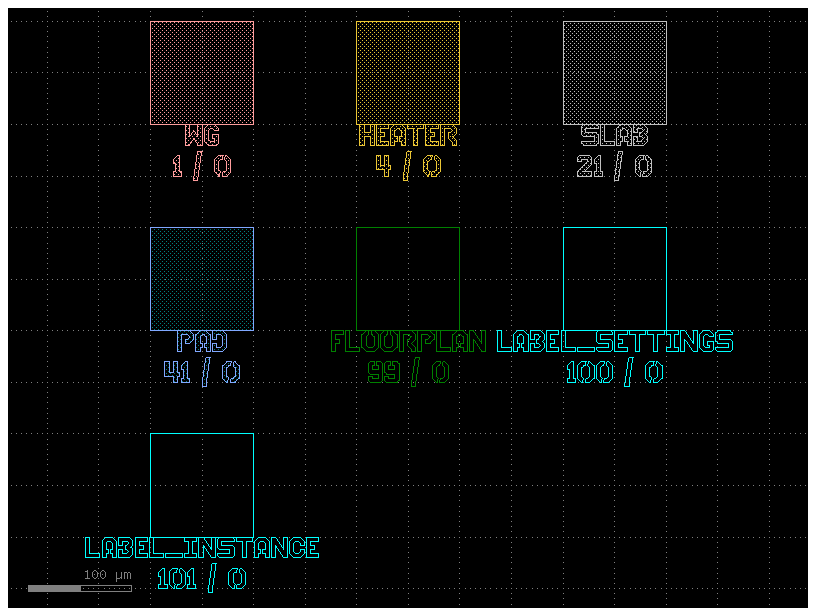

In [79]:
LAYER_VIEWS = PDK.layer_views
c = LAYER_VIEWS.preview_layerset()
c.show()
c.plot()


The new versions of GDS Factory allow to view the Layer Stack also (3D view of the fabrication flow). The following code allows to generate and view the Layer Stack of the generic PDK. Reference: https://www.degruyter.com/document/doi/10.1515/nanoph-2013-0034/html

The layers and the thicknesses have been defined previously on the PDK, so it is possible to view in 3D some of the components in the PDK. 

See the [Reference Manual](https://gdsfactory.github.io/gdsfactory/components.html) and read the list of the available components.

Here are some examples of the 3D views of this photonic components

2026-06-12 12:44:06.147 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


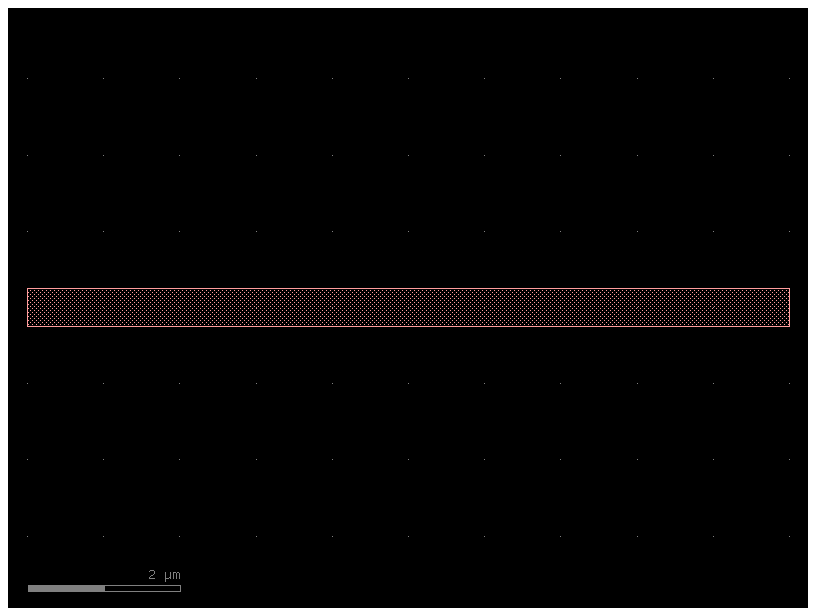

In [80]:
xs = gf.cross_section.strip(width=0.5, layer = 'WG')

c = gf.components.straight(length=10, cross_section=xs)  #Deep 
c.plot() # To view the component on Notebook
c.show() # To view on KLayout
scene = c.to_3d()
scene.show()


2026-06-12 12:44:06.547 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server
2026-06-12 12:44:06.611 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


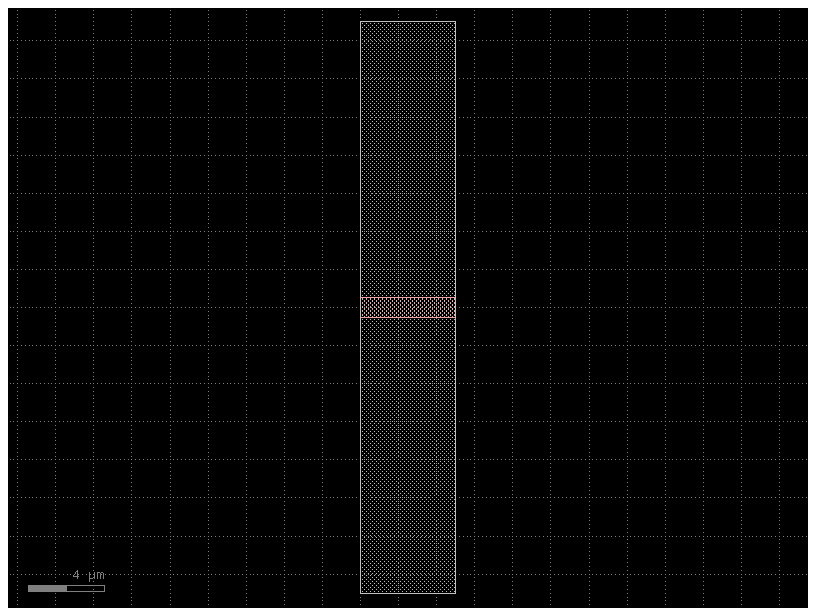

In [81]:
c = gf.components.straight(length=5, cross_section='rib') #Shallow
c.plot()
c.show()

scene = c.to_3d()
c.show()
scene.show()

In [82]:
c = cells.taper_strip_to_ridge(length=10) #Taper
c.show()

scene = c.to_3d()
scene.show()

2026-06-12 12:44:06.952 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


2026-06-12 12:44:07.416 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


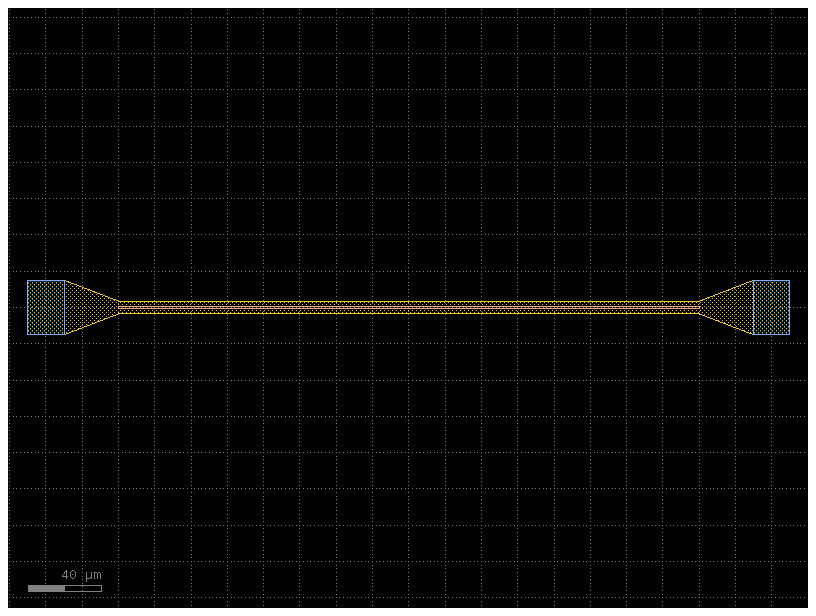

In [83]:
c = cells.straight_heater_metal()

#c.pprint_ports()

c.plot()
c.show()
#c.draw_ports()

scene = c.to_3d()
scene.show()

- Use your design results from Lab2 and Lab3 to create **layout** instances of your designed components: DCs, MMIs, MZIs & Ring Resonators. 

2026-06-12 12:44:07.915 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


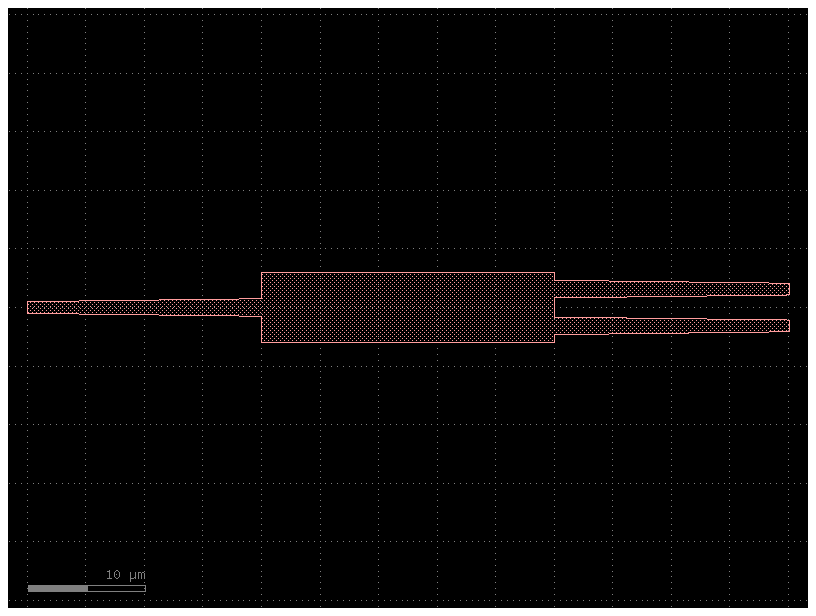

In [ ]:
# --- MMI 1x2 ---
c_mmi1x2 = cells.mmi1x2(length_mmi=25.055)
c_mmi1x2.plot()
c_mmi1x2.show()

2026-06-12 12:44:08.275 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


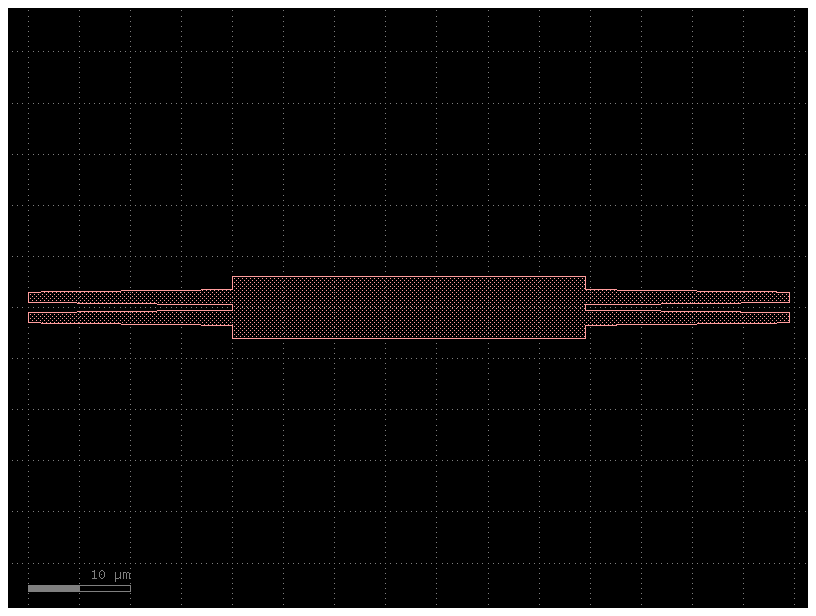

In [ ]:
# --- MMI 2x2 ---
c_mmi2x2 = cells.mmi2x2(length_mmi=34.518)
c_mmi2x2.plot()
c_mmi2x2.show()

2026-06-12 12:44:08.700 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


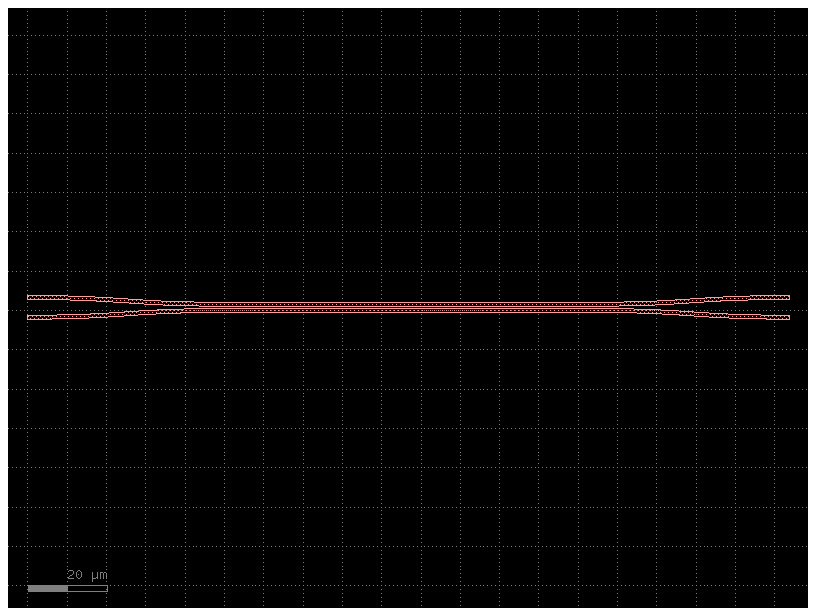

In [ ]:
# --- Directional Coupler (DC) ---
c_dc = gf.components.coupler(gap=0.6, length=93.83, dx=50, dy=5, cross_section='strip')
c_dc.plot()
c_dc.show()

2026-06-12 12:44:09.076 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


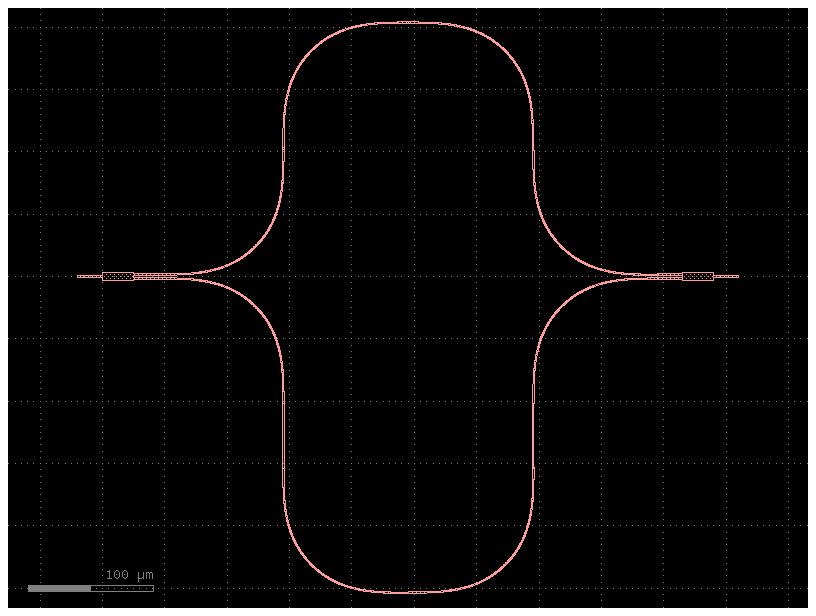

In [ ]:
# --- MZI using MMI 1x2 ---
c_mzi = gf.components.mzi(delta_length=100.0, splitter=c_mmi1x2, combiner=c_mmi1x2)
c_mzi.plot()
c_mzi.show()

2026-06-12 12:44:09.571 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


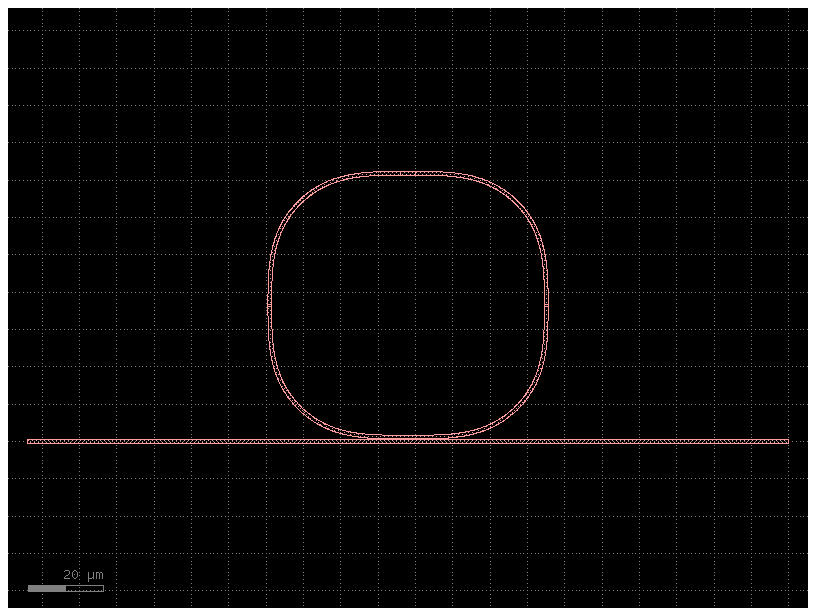

In [ ]:
# --- Ring Resonator ---
c_ring = gf.components.ring_single(radius=35.0, gap=0.2, length_x=4, cross_section='strip')
c_ring.plot()
c_ring.show()

## 2. Layout Fundamentals

A cell is a function that returns a Component. In GDS each component must have a unique name. Two components stored in the GDS file cannot have the same name. They need to be references (instances) of the same component.

![GDSFactoryComponents][def]


[def]: https://i.imgur.com/oeuKGsc.png

2026-06-12 12:44:10.050 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


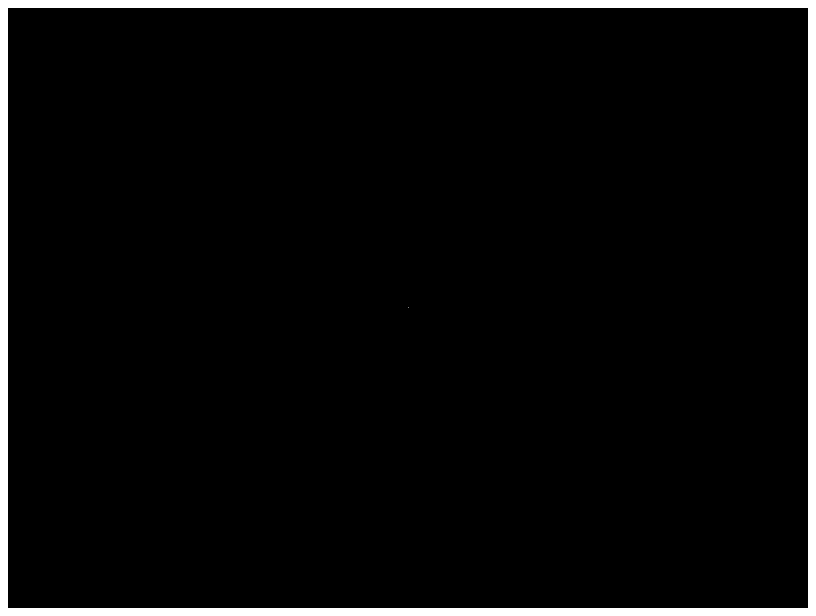

In [89]:
c = gf.Component()
c.plot()
c.show()

Let's build a Component from scratch. A die (chip) for a photonic layout. The PDK or Design Manual should specify the Layer for the bounding box (dicing line). 
We should also consider: 
1. The die dimensions and 
2. The border for dicing 

2026-06-12 12:44:10.332 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


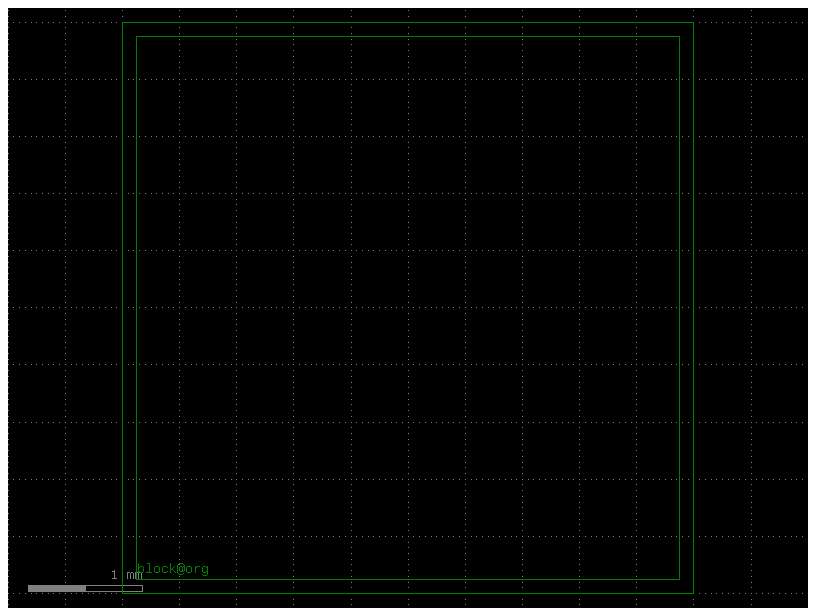

In [90]:
wgw = 0.5
dieL = 5000
dieW = 5000
border = 125
layer_wg = "WG"
layer_box = "FLOORPLAN"

# Die specifications (Chip)
box = gf.Component()

obox = box.add_ref(gf.components.rectangle(size=(dieW,dieL),layer=layer_box))
ibox = box.add_ref(gf.components.rectangle(size=(dieW-border*2,dieL-border*2),layer=layer_box)).dmovex(border).dmovey(border)
box = gf.boolean(A=obox, B=ibox, operation="A-B", layer="FLOORPLAN")

# Adding ports to a component 
box.add_port(name="block@org", center=[border,border], width=1, orientation=0, layer=layer_box)

box.draw_ports()
box.show()
box.plot()

### Mantra: 
Once that we have a working 'new' component, we shall convert it into a Cell. This will allow us to have a hierarchical design

2026-06-12 12:44:10.735 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


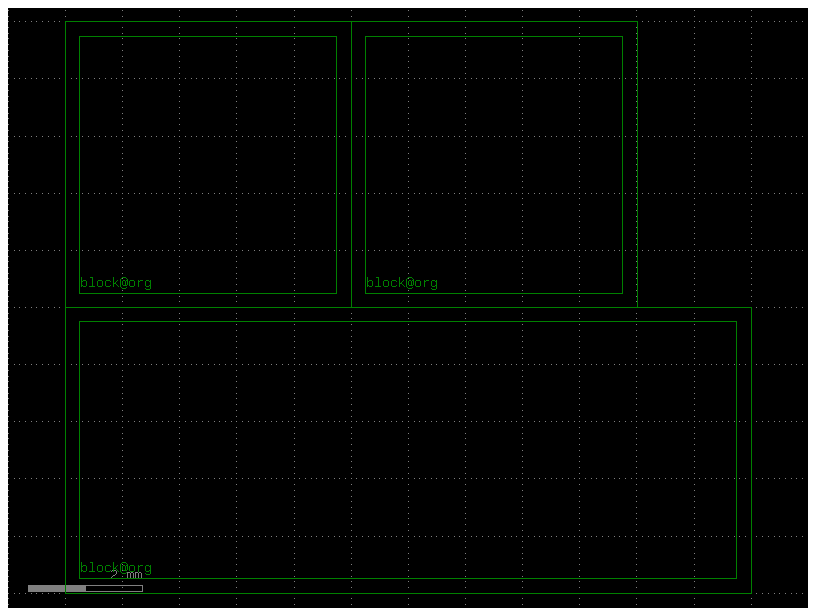

In [91]:
# 1. We define the cell as a function with it's corresponding parameters (and defaults)
gf.clear_cache()

@gf.cell
def die(dieL = 5000, dieW = 5000, border = 250, layer_box = "FLOORPLAN"):
    # Die specifications (Chip)
    box = gf.Component()
    obox = box.add_ref(gf.components.rectangle(size=(dieW,dieL),layer=layer_box))
    ibox = box.add_ref(gf.components.rectangle(size=(dieW-border*2,dieL-border*2),layer=layer_box)).dmovex(border).dmovey(border)
    box = gf.boolean(A=obox, B=ibox, operation="A-B", layer=layer_box)
    # Adding ports to a component 
    box.add_port(name="block@org", center=[border,border], width=1, orientation=0, layer=layer_box)
    box.draw_ports()
    return box

# 2. We instantiate references of each cell. We can also name it individually to avoid problems
wafer = gf.Component()
dieW1 = 5000
dieW2 = 10000

c1 = wafer.add_ref(die(dieW = dieW))
c2 = wafer.add_ref(die(dieW = dieW))
c3 = wafer.add_ref(die(dieW = 12000))

c2.dmovex(dieW1)
c3.dmovey(-5000)
wafer.show()
wafer.plot()


2026-06-12 12:44:11.156 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


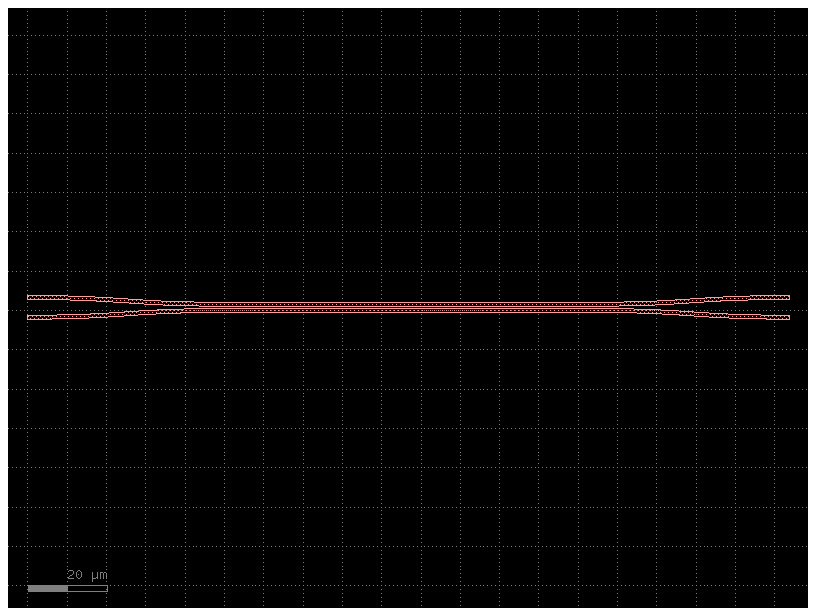

In [92]:
# --- Cell: Directional Coupler (DC) ---
gf.clear_cache()

@gf.cell
def cell_dc(gap=0.6, length=93.83, dx=50, dy=5, cross_section='strip'):
    """Directional Coupler from Lab 2. K=0.5, gap=600nm, L_pi_TE=93.83 um."""
    c = gf.components.coupler(gap=gap, length=length, dx=dx, dy=dy, cross_section=cross_section)
    return c

c_cell_dc = cell_dc()
c_cell_dc.plot()
c_cell_dc.show()

2026-06-12 12:44:11.537 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


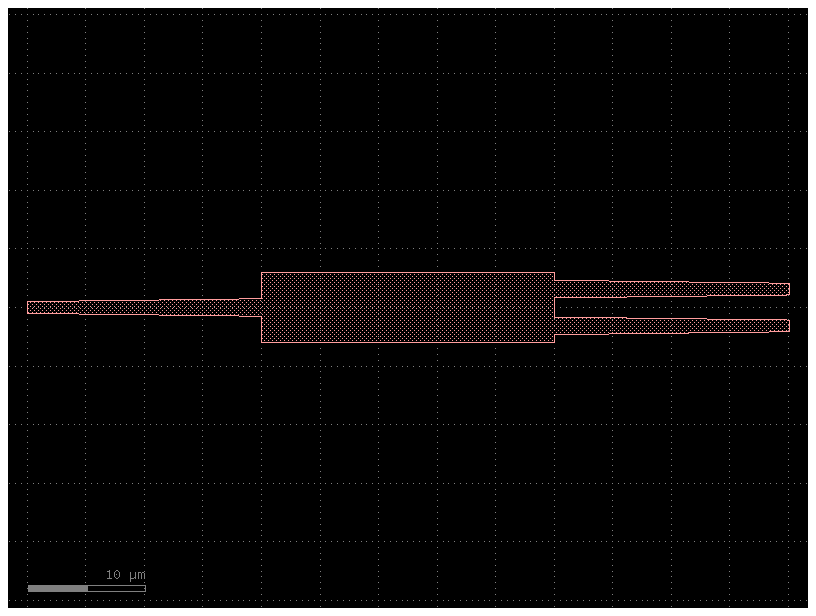

In [93]:
# --- Cell: MMI 1x2 ---
gf.clear_cache()

@gf.cell
def cell_mmi1x2(length_mmi=25.055):
    """MMI 1x2 from Lab 2. Symmetric interference, 50:50 splitter. L_MMI=25.055 um."""
    c = cells.mmi1x2(length_mmi=length_mmi)
    return c

c_cell_mmi1x2 = cell_mmi1x2()
c_cell_mmi1x2.plot()
c_cell_mmi1x2.show()

2026-06-12 12:44:11.876 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


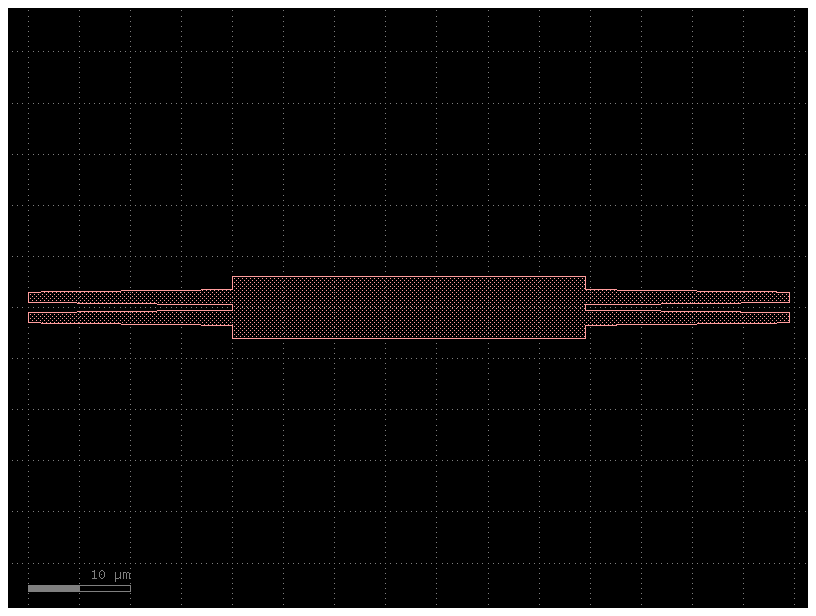

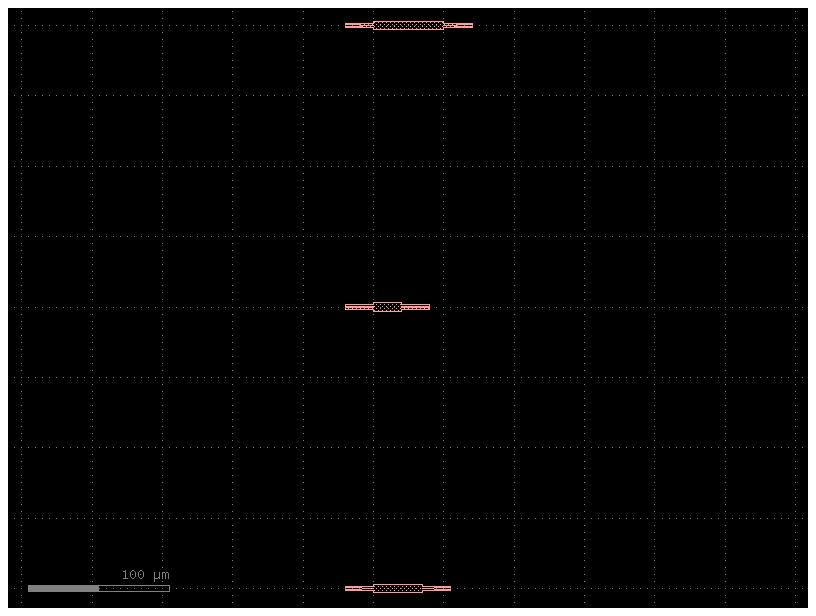

In [94]:
# --- Cell: MMI 2x2 ---
gf.clear_cache()

@gf.cell
def cell_mmi2x2(length_mmi=34.518):
    """MMI 2x2 from Lab 2. Paired interference, K=0.5. L_MMI=34.518 um."""
    c = cells.mmi2x2(length_mmi=length_mmi)
    return c

c_cell_mmi2x2 = cell_mmi2x2()
c_cell_mmi2x2.plot()
c_cell_mmi2x2.show()

chip_de_pruebas=gf.Component("Mi_Chip")

mmi_estandar = chip_de_pruebas.add_ref(cell_mmi2x2(length_mmi=34.518))

mmi_corto = chip_de_pruebas.add_ref(cell_mmi2x2(length_mmi=20.0))
mmi_corto.dmovey(200) 

mmi_largo = chip_de_pruebas.add_ref(cell_mmi2x2(length_mmi=50.0))
mmi_largo.dmovey(400) 

chip_de_pruebas.plot()

2026-06-12 12:44:12.563 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


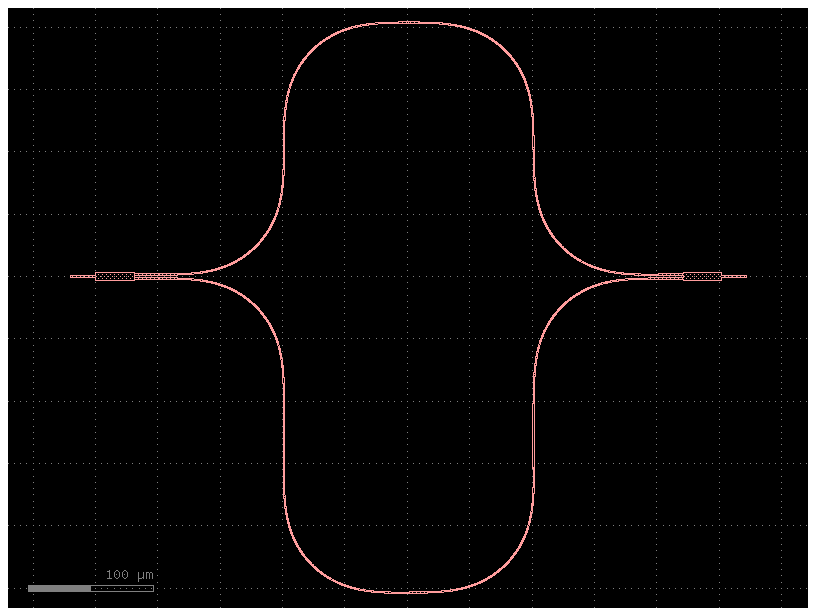

In [95]:
# --- Cell: MZI (using MMI 1x2) ---
gf.clear_cache()

@gf.cell
def cell_mzi(delta_length=100.0):
    """MZI using MMI 1x2 as splitter and combiner. delta_length=100 um from Lab 3."""
    splitter = cells.mmi1x2()
    combiner = cells.mmi1x2()
    c = gf.components.mzi(delta_length=delta_length, splitter=splitter, combiner=combiner)
    return c

c_cell_mzi = cell_mzi()
c_cell_mzi.plot()
c_cell_mzi.show()

2026-06-12 12:44:10.547 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


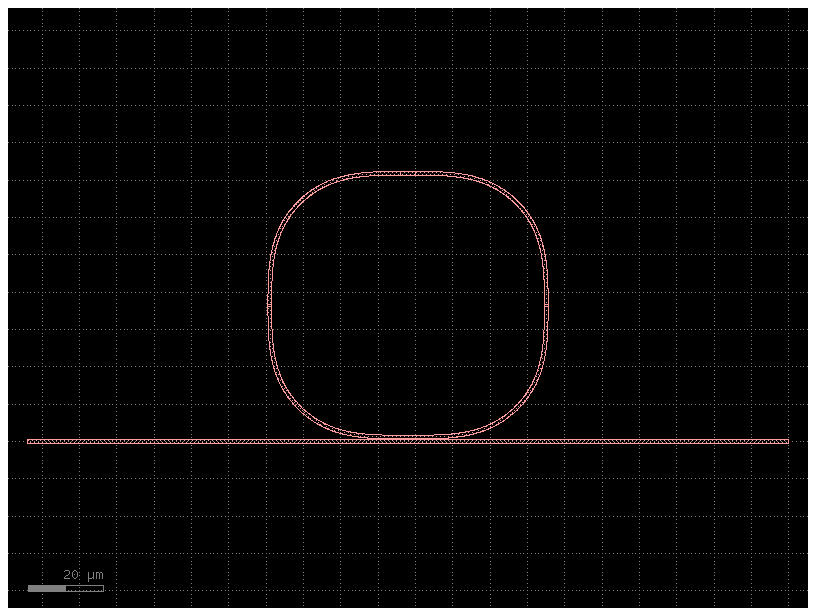

In [96]:
# --- Cell: Ring Resonator ---
gf.clear_cache()

@gf.cell
def cell_ring(radius=35.0, gap=0.2, length_x=4, cross_section='strip'):
    """Ring resonator. PDK minimum radius=35 um. Perimeter ideal Lab3=80.08 um."""
    c = gf.components.ring_single(radius=radius, gap=gap, length_x=length_x, cross_section=cross_section)
    return c

c_cell_ring = cell_ring()
c_cell_ring.plot()
c_cell_ring.show()

## 3. Complete Layout

2026-06-12 12:44:10.994 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


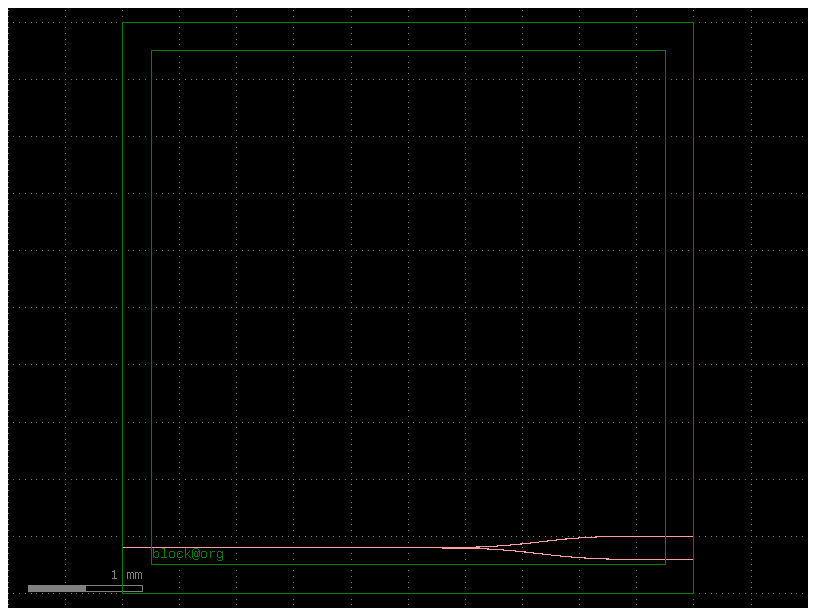

In [97]:
layer_wg  = "WG"
minrad = 50
dieW = 5000

main = gf.Component()

die_ref = main.add_ref(die(dieW = dieW, layer_box="FLOORPLAN"))

## Add first a test MMI routed from side to side
c_mmi = cells.mmi1x2()
mmi = main.add_ref(c_mmi)
mmi.dmovex(die_ref["block@org"].dx + 0.5*dieW).dmovey(die_ref['block@org'].dy + 150)

## Route waveguides from MMI to the die edges
xs = 'strip'
### First add the i/o waveguides - to be sure you 'cut' on a straight section
strin = (main.add_ref(gf.components.straight(length=500, cross_section='strip')).dmovex(0).dmovey(mmi['o1'].dy))
strout1 = (main.add_ref(gf.components.straight(length=500, cross_section=xs)).drotate(180).dmovey(mmi.ports['o3'].dy-100).dmovex(dieW))
strout2 = (main.add_ref(gf.components.straight(length=500, cross_section=xs)).drotate(180).dmovey(mmi.ports['o2'].dy+100).dmovex(dieW))
### Then route from the i/o waveguides to the MMI
gf.routing.route_single_sbend(main,port1=strin['o2'], port2=mmi['o1'], cross_section=xs)
gf.routing.route_single_sbend(main,port1=mmi['o2'], port2=strout2['o2'], cross_section=xs)
gf.routing.route_single_sbend(main,port1=mmi['o3'], port2=strout1['o2'], cross_section=xs)

main.plot()
main.show()

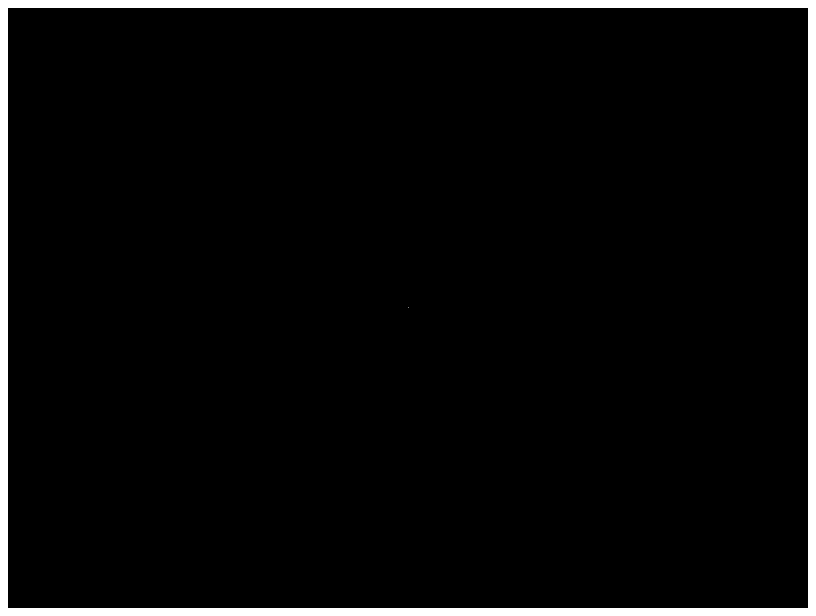

In [98]:
# Let's create a MMI tree

c = gf.Component()
c_mmi = cells.mmi1x2()

#...

c.plot()

In [99]:
# Once we "test" the high-level component, we can create a cell for it
@gf.cell 
def mmi_tree_1x4(pad_x = 250 ,pad_y = 250):
    c = gf.Component()
    c_mmi = cells.mmi1x2()
    mmi1 = c.add_ref(c_mmi)
    mmi2 = c.add_ref(c_mmi)
    mmi3 = c.add_ref(c_mmi)

    mmi2.dmovex(pad_x).dmovey(pad_y)
    mmi3.dmovex(pad_x).dmovey(-pad_y)

    gf.routing.route_single_sbend(component=c, port1= mmi1['o2'], port2=mmi2['o1'],cross_section='strip')
    gf.routing.route_single_sbend(component=c, port1= mmi1['o3'], port2=mmi3['o1'],cross_section='strip')
    c.add_port(name='o1', port=mmi1['o1'])
    c.add_port(name='o2', port=mmi2['o2'])
    c.add_port(name='o3', port=mmi2['o3'])
    c.add_port(name='o4', port=mmi3['o2'])
    c.add_port(name='o5', port=mmi3['o3'])
    c.draw_ports()
    return c

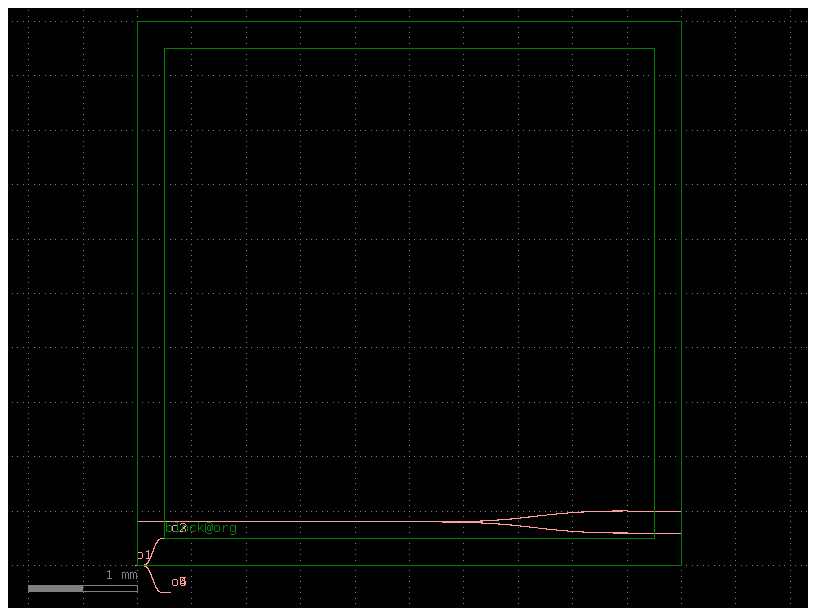

In [100]:
# With the cell created, we can instantiate and use it in our main component

cell_1x4 = main.add_ref(mmi_tree_1x4())
main.plot()


2026-06-12 12:44:12.533 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


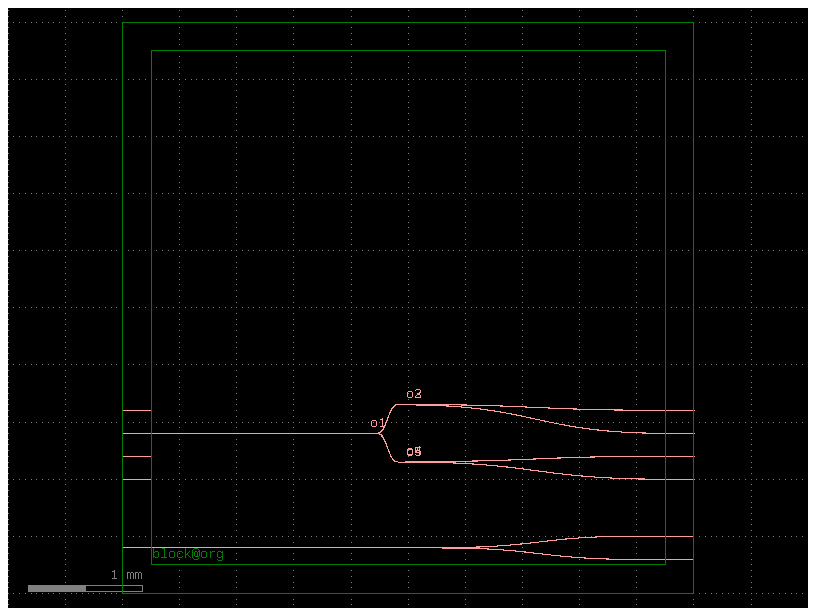

In [101]:
## Arrayed waveguides and MMI tree

sp = 200
border = 250

in_arr = main.add_ref(
    gf.components.straight_array(n=4, spacing=sp, length=border, cross_section=xs)
).dmovey(
    1000
)  #!!!!!! Easy to put IO Waveguides for a complete design !!!!

out_arr = (
    main.add_ref(
        gf.components.straight_array(n=4, spacing=sp, length=border, cross_section=xs)
    )
    .dmovex(dieW - border)
    .dmovey(1000)
)

cell_1x4.dmovex(0.5*dieW - mmi_tree_1x4().dxsize).dmovey(in_arr['o6'].dy)
gf.routing.route_single_sbend(component=main, port1=in_arr['o6'], port2=cell_1x4['o1'])
gf.routing.route_single_sbend(component=main, port1=cell_1x4['o2'], port2=out_arr['o4'])
gf.routing.route_single_sbend(component=main, port1=cell_1x4['o3'], port2=out_arr['o3'])
gf.routing.route_single_sbend(component=main, port1=cell_1x4['o4'], port2=out_arr['o2'])
gf.routing.route_single_sbend(component=main, port1=cell_1x4['o5'], port2=out_arr['o1'])
main.plot()
main.show()

### Mantra:
It's useful to use memorize this mantra: 
- Add_references 
- Connect_them
- Move_them

### Other Routing options examples:

Please check the GDSFactory Routing API for more information about advanced routing functionalities

[Routing API](https://gdsfactory.github.io/gdsfactory/api_routing.html) 

## 4. Exercises. 

Part a) Creating components
- Create a cell component for a unbalanced MZI, using 2x2 50:50 MMIs with arm length difference as parameter
- Create a cell component based on the previous, where the arms have thermal tuners on top of each one
- Create a cell component for an all-pass ring resonator, using 2x2 50:50 MMIs, with extra length parameter for different perimeters
- Create a cell component based on the previous, where the ring has a thermal tuner on top along all the perimeter
- Create a cell component based on existing GDSfactory spiral components, with length as parameter

Part b) Creating die
- Create a die  W = 5 mm x L = 10 mm 
- Create an array of I/Os spaced at 250 µm (as much I/Os as the width allows)
- Create a cell component of this die, with I/Os accessible to connect

Part c) Floorplaning and die layout
- Make an instance of the die as host component for your layout
- Add 3 sets of 3 straight waveguides, from left to right of the die, top, middle and bottom of the die
- Add 2 of each of the components above, with different lengths
- Connect all your components to the I/Os 

### a) Creating components

2026-06-12 12:44:13.009 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


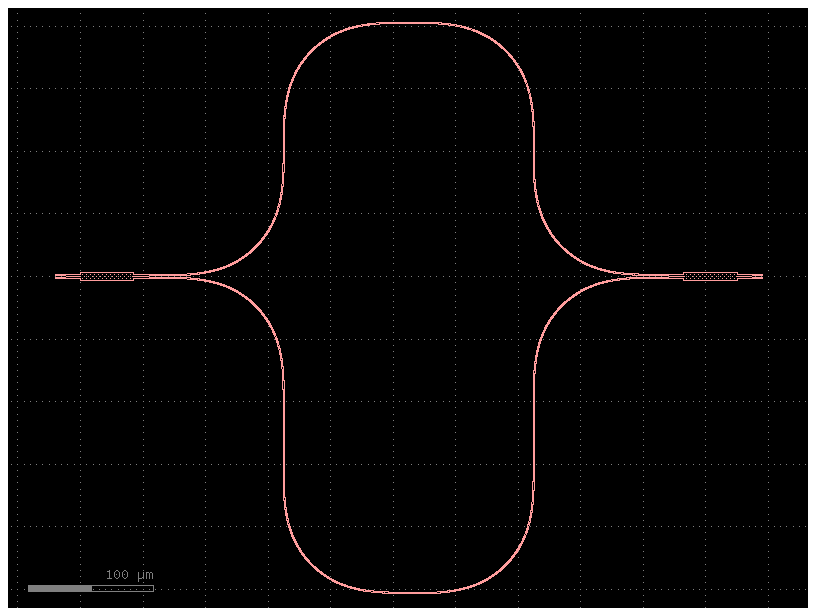

In [ ]:
# cell component for a unbalanced MZI, using 2x2 50:50 MMIs with arm length difference as parameter
gf.clear_cache()
@gf.cell
def mzi_mmi(delta_length=100):
    return gf.components.mzi(
        delta_length=delta_length,
        splitter=cells.mmi2x2,
        combiner=cells.mmi2x2,
        port_e1_splitter="o3",
        port_e0_splitter="o4",
        port_e1_combiner="o3",
        port_e0_combiner="o4",
    )

c = mzi_mmi()
c.plot()
c.show()

2026-06-12 12:44:13.695 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


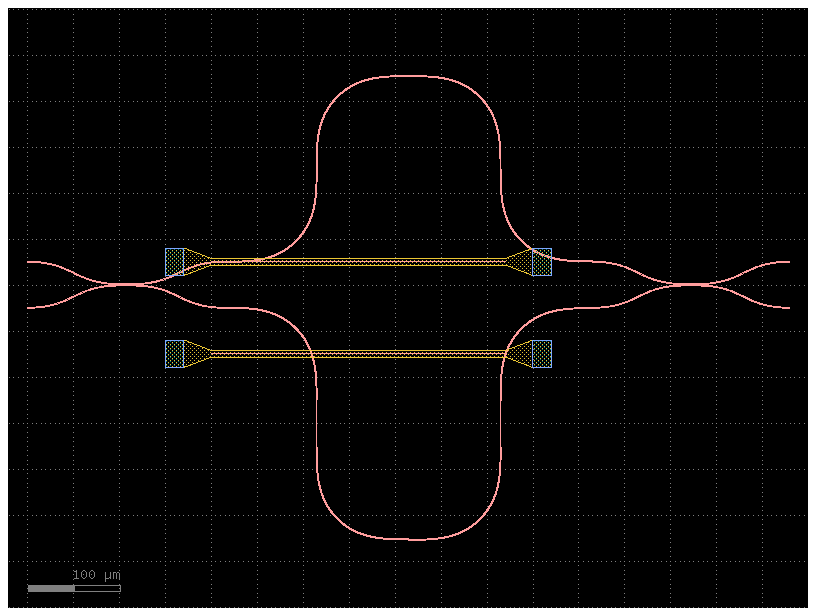

In [ ]:
# cell component based on the previous, where the arms have thermal tuners on top of each one


@gf.cell
def mzi_mmi_heater(delta_length=100):
    c = gf.Component()
    mzi_ref = c.add_ref(cells.mzi(delta_length=delta_length))
    h1 = c.add_ref(cells.straight_heater_metal())
    h2 = c.add_ref(cells.straight_heater_metal())
    h1.dmovex(mzi_ref.dxmin + 200).dmovey(mzi_ref.dy + 50)
    h2.dmovex(mzi_ref.dxmin + 200).dmovey(mzi_ref.dy - 50)

    c.add_port('o1', port=mzi_ref.ports['o1'])
    c.add_port('o2', port=mzi_ref.ports['o2'])
    return c

c = mzi_mmi_heater()
c.plot()
c.show()

2026-06-12 12:44:14.205 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


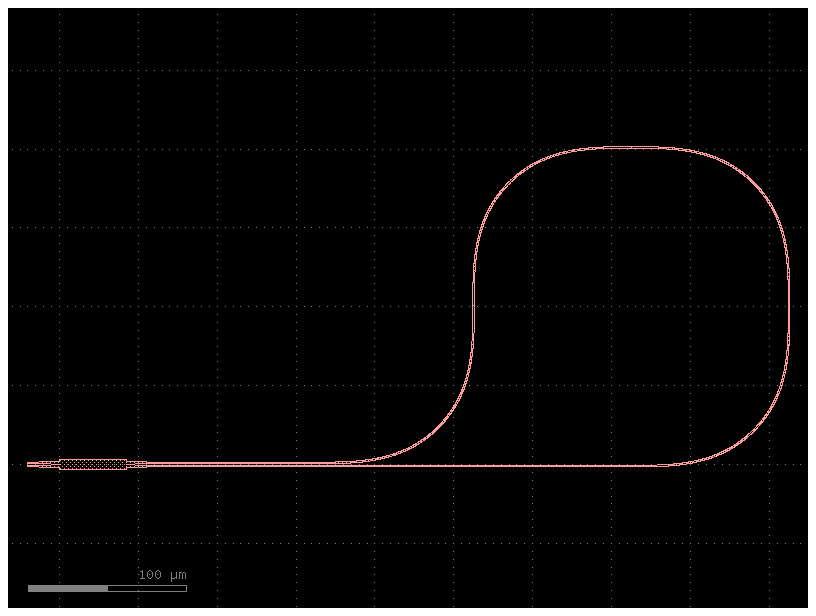

In [ ]:
#cell component for an all-pass ring resonator, using 2x2 50:50 MMIs, with extra length parameter for different perimeters

@gf.cell
def ring_mmi(extra_length=100):
    c = gf.Component()
    mmi = c.add_ref(cells.mmi2x2())

    wg = c.add_ref(gf.components.straight(length=extra_length, cross_section='strip'))
    wg.connect('o1', mmi.ports['o3'])

    gf.routing.route_single(c, wg.ports['o2'], mmi.ports['o4'], cross_section='strip')

    c.add_port('o1', port=mmi['o1'])
    c.add_port('o2', port=mmi['o2'])
    return c

c = ring_mmi(extra_length=100)
c.plot()
c.show()

2026-06-12 12:44:14.689 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


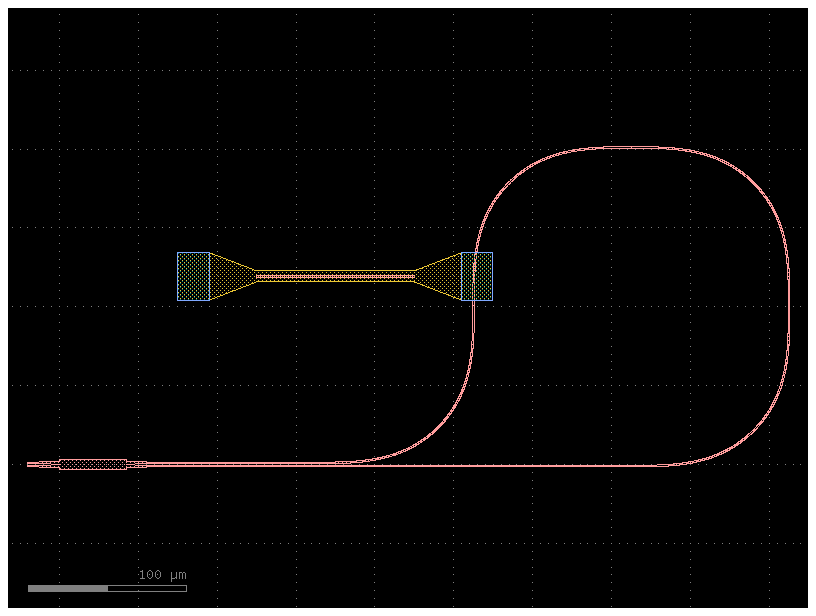

In [ ]:
# cell component based on the previous, where the ring has a thermal tuner on top along all the perimeter

@gf.cell
def ring_mmi_heater(extra_length=100):
    c = gf.Component()
    ring_ref = c.add_ref(ring_mmi(extra_length=extra_length))
    h = c.add_ref(cells.straight_heater_metal(length=extra_length))
    h.dmovex(ring_ref.dxmin + ring_ref.dxsize * 0.3).dmovey(ring_ref.dy + 20)

    c.add_port('o1', port=ring_ref.ports['o1'])
    c.add_port('o2', port=ring_ref.ports['o2'])
    return c

c = ring_mmi_heater(extra_length=100)
c.plot()
c.show()

2026-06-12 12:44:15.175 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


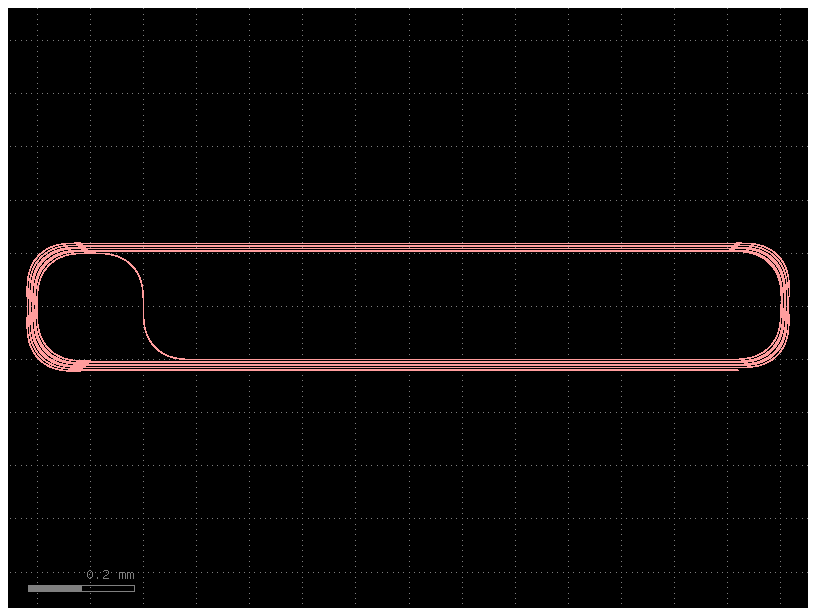

In [ ]:
# cell component based on existing GDSfactory spiral components, with length as parameter

gf.clear_cache()

@gf.cell
def cell_spiral(length=1000.0, spacing=3.0, cross_section="strip"):
    """Spiral delay line. length controla la longitud total de guía de onda.
    spacing: separación entre vueltas. Aplican restricciones de radio mínimo del PDK."""
    c = gf.components.spiral(
        length=length,
        spacing=spacing,
        cross_section=cross_section,
    )
    return c

c_spiral = cell_spiral()
c_spiral.plot()
c_spiral.show()

### b) Creating die

I/Os: 38
2026-06-12 12:44:15.613 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


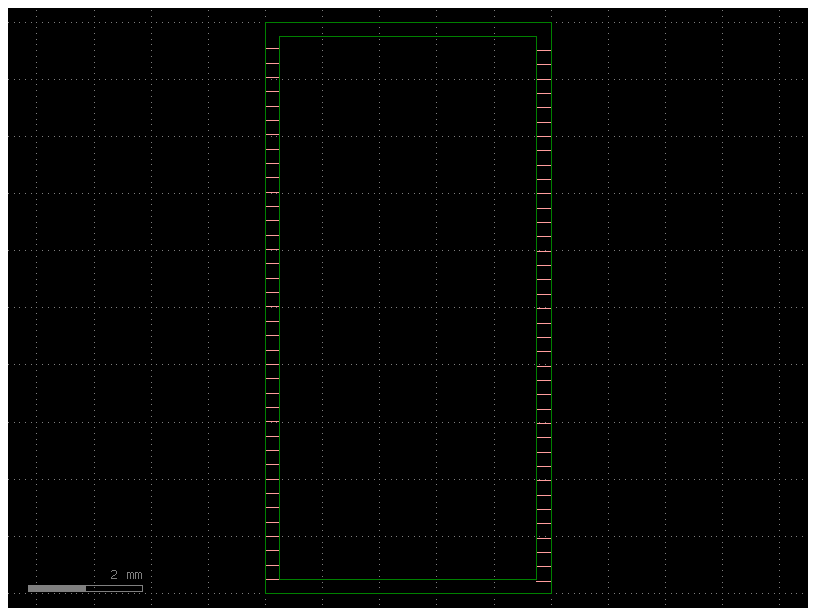

In [ ]:
# - Create a die  W = 5 mm x L = 10 mm 
# - Create an array of I/Os spaced at 250 µm (as much I/Os as the width allows)
# - Create a cell component of this die, with I/Os accessible to connect

@gf.cell
def die_b(dieW=5000, dieL=10000, border=250, io_spacing=250):
    c = gf.Component()

    obox = c.add_ref(gf.components.rectangle(size=(dieW, dieL), layer="FLOORPLAN"))
    ibox = c.add_ref(gf.components.rectangle(
        size=(dieW - 2*border, dieL - 2*border), layer="FLOORPLAN"
    )).dmovex(border).dmovey(border)
    frame = gf.boolean(A=obox, B=ibox, operation="A-B", layer="FLOORPLAN")
    c.add_ref(frame)

    n_ios = int((dieL - 2*border) / io_spacing)
    print(f"I/Os: {n_ios}")

    io_in = c.add_ref(gf.components.straight_array(
        n=n_ios, spacing=io_spacing, length=border, cross_section='strip'
    )).dmovex(0).dmovey(border)

    io_out = c.add_ref(gf.components.straight_array(
        n=n_ios, spacing=io_spacing, length=border, cross_section='strip'
    )).drotate(180).dmovex(dieW).dmovey(border + (n_ios - 1) * io_spacing)

    c.add_port(name="block@org", center=[border, border], width=1, orientation=0, layer="FLOORPLAN")


    return c

c = die_b()
c.plot()
c.show()

### c) Floorplanning and die layout

2026-06-12 12:46:56.451 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


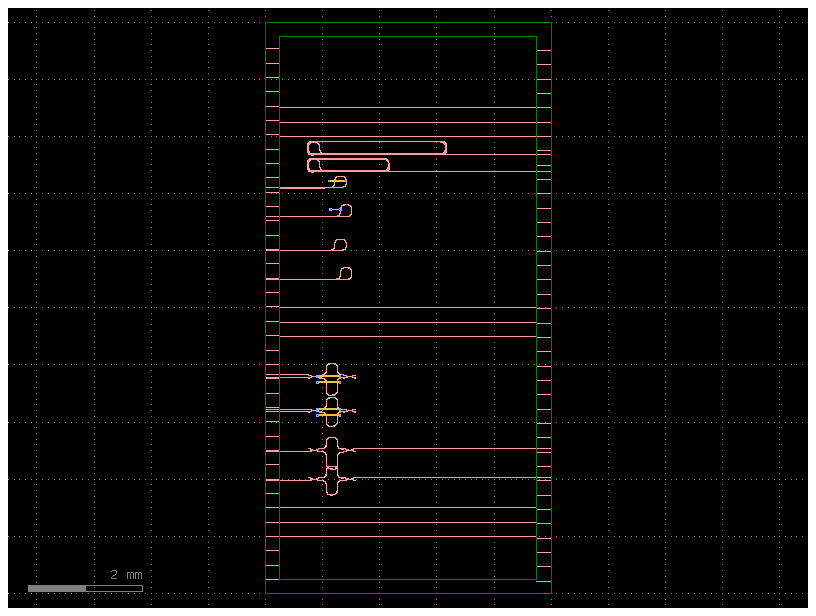

In [ ]:
# - Make an instance of the die as host component for your layout
# - Add 3 sets of 3 straight waveguides, from left to right of the die, top, middle and bottom of the die
# - Add 2 of each of the components above, with different lengths
# - Connect all your components to the I/Os 

dieW, dieL, border = 5000, 10000, 250
xs = 'strip'

layout = gf.Component()
layout.add_ref(die_b())

wg_len = dieW - 2*border
for i in range(3):
    layout.add_ref(gf.components.straight(length=wg_len, cross_section=xs)).dmovex(border).dmovey(1000 + i*250)
for i in range(3):
    layout.add_ref(gf.components.straight(length=wg_len, cross_section=xs)).dmovex(border).dmovey(4500 + i*250)
for i in range(3):
    layout.add_ref(gf.components.straight(length=wg_len, cross_section=xs)).dmovex(border).dmovey(8000 + i*250)

mzi1  = layout.add_ref(cells.mzi(delta_length=100)).dmovex(border+600).dmovey(2000)
mzi2  = layout.add_ref(cells.mzi(delta_length=200)).dmovex(border+600).dmovey(2500)
mzih1 = layout.add_ref(mzi_mmi_heater(delta_length=100)).dmovex(border+600).dmovey(3200)
mzih2 = layout.add_ref(mzi_mmi_heater(delta_length=200)).dmovex(border+600).dmovey(3800)
ring1  = layout.add_ref(ring_mmi(extra_length=100)).dmovex(border+800).dmovey(5500)
ring2  = layout.add_ref(ring_mmi(extra_length=200)).dmovex(border+800).dmovey(6000)
ringh1 = layout.add_ref(ring_mmi_heater(extra_length=100)).dmovex(border+800).dmovey(6600)
ringh2 = layout.add_ref(ring_mmi_heater(extra_length=200)).dmovex(border+800).dmovey(7100)
sp1 = layout.add_ref(cell_spiral(length=1000)).dmovex(border+800).dmovey(7400)
sp2 = layout.add_ref(cell_spiral(length=2000)).dmovex(border+800).dmovey(7700)

def connect_lr(ref, port_in, port_out):
    wg_in = layout.add_ref(gf.components.straight(length=border, cross_section=xs))
    wg_in.dmovex(0).dmovey(ref.ports[port_in].dy)
    wg_out = layout.add_ref(gf.components.straight(length=border, cross_section=xs))
    wg_out.drotate(180).dmovex(dieW).dmovey(ref.ports[port_out].dy)
    gf.routing.route_single_sbend(layout, wg_in['o2'], ref.ports[port_in], cross_section=xs)
    gf.routing.route_single_sbend(layout, ref.ports[port_out], wg_out['o2'], cross_section=xs)

def connect_left(ref, port1, port2):
    for p in [port1, port2]:
        wg = layout.add_ref(gf.components.straight(length=border, cross_section=xs))
        wg.dmovex(0).dmovey(ref.ports[p].dy)
        gf.routing.route_single_sbend(layout, wg['o2'], ref.ports[p], cross_section=xs)

def connect_right(ref, port1, port2):
    for p in [port1, port2]:
        wg = layout.add_ref(gf.components.straight(length=border, cross_section=xs))
        wg.drotate(180).dmovex(dieW).dmovey(ref.ports[p].dy)
        gf.routing.route_single_sbend(layout, ref.ports[p], wg['o2'], cross_section=xs)

connect_lr(mzi1, 'o1', 'o3')
connect_lr(mzi2, 'o1', 'o3')
connect_left(mzih1, 'o1', 'o2')
connect_left(mzih2, 'o1', 'o2')
connect_left(ring1,  'o1', 'o2')
connect_left(ring2,  'o1', 'o2')
connect_left(ringh1, 'o1', 'o2')
connect_left(ringh2, 'o1', 'o2')
connect_right(sp1, 'o1', 'o2')
connect_right(sp2, 'o1', 'o2')

layout.plot()
layout.show()